# 1. Split

from sklearn.model_selection import 

In [2]:
import warnings
from sklearn.exceptions import FitFailedWarning

# Suppress FutureWarnings and FitFailedWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('data/clean_data_v1.csv')
df = df.drop(columns="Unnamed: 0")
df.head()


,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [5]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]

X

,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1,15634602,619,0,0,42,2,0.00,1,1,1,101348.88
1,2,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58
2,3,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57
3,4,15701354,699,0,0,39,1,0.00,2,0,0,93826.63
4,5,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,0,1,39,5,0.00,2,1,0,96270.64
9996,9997,15569892,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,9998,15584532,709,0,0,36,7,0.00,1,0,1,42085.58
9998,9999,15682355,772,1,1,42,3,75075.31,2,1,0,92888.52


In [6]:
TRAINING_SIZE = 0.8
RANDOM_STATE = 42

In [7]:
x_train_unbalanced, x_temp, y_train_unbalanced, y_temp = train_test_split(X, y, train_size=TRAINING_SIZE, random_state=RANDOM_STATE)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

print(len(x_train_unbalanced))
print(len(x_val))
print(len(x_test))

8000
1000
1000


# Balancing Training Dataset 

<Axes: >

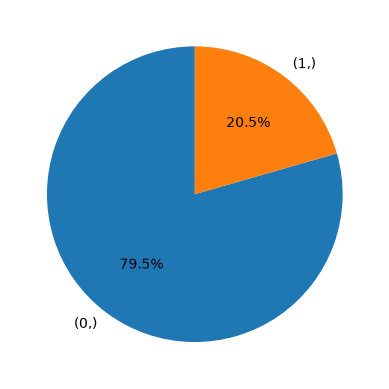

In [8]:
pd.DataFrame(y_train_unbalanced).value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

In [9]:
x_train = x_train_unbalanced
y_train = y_train_unbalanced

In [10]:
# # train_df = pd.DataFrame(x_train_unbalanced)
# # train_df['target'] = y_train_unbalanced

# # df_exited = train_df[train_df['target']==1]
# # df_not_exited = train_df[train_df['target']==0]

# # print("Before Balancing")
# # display(train_df['target'].describe())

# # df_not_exited = df_not_exited.sample(n=len(df_exited), random_state=RANDOM_STATE)
# # train_df = pd.concat([df_exited, df_not_exited])

# # print("="*50)
# # print("After Balancing")
# # display(train_df['target'].describe())

# x_train = train_df.iloc[:,:-1]
# y_train = train_df.iloc[:,-1]

# 2. Training 

In [11]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, recall_score, precision_score, RocCurveDisplay, roc_curve

In [55]:
def display_metric(y_true, y_pred, name=None, ConfusionMatrix=True):


    f1 = f1_score(y_true=y_true, y_pred=y_pred)
    recall = recall_score(y_true=y_true, y_pred=y_pred)
    precision = precision_score(y_true=y_true, y_pred=y_pred)

    print("f1_score:", f"%{round(f1*100,4)}")
    print("recall_score:", f"%{round(recall*100,4)}")
    print("precision_score:", f"%{round(precision*100,4)}")

    if name:
        plt.title(name)

    if ConfusionMatrix:
        ConfusionMatrixDisplay.from_predictions(y_true=y_true, y_pred=y_pred)
    print("-"*50)

    return f1, recall, precision


    

In [52]:
def get_best_threshold(y_test, y_pred, printing=True):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)

    best_threshold = thresholds[best_idx]
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]

    if printing:
        print(f"Optimal Threshold: {best_threshold:.4f}")
        print(f"At this threshold -> TPR (Recall): {best_tpr:.4f}, FPR: {best_fpr:.4f}")

    return best_threshold


### 2.1 Logisitic Regression

In [14]:
def get_logisitic_regression():
    first_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE))
    ])

    params_grid = {
        "classifier__C":[0.01, 0.1, 1],
        "classifier__penalty":["l1", "l2"],
        "classifier__solver":["liblinear", "newton-cg", "sag"]
    }

    gridSearch = GridSearchCV(estimator=first_pipeline, param_grid=params_grid, cv=5, scoring="f1")
    gridSearch.fit(x_train, y_train)

    return gridSearch

f1_score: %24.6696
recall_score: %15.7303
precision_score: %57.1429
--------------------------------------------------


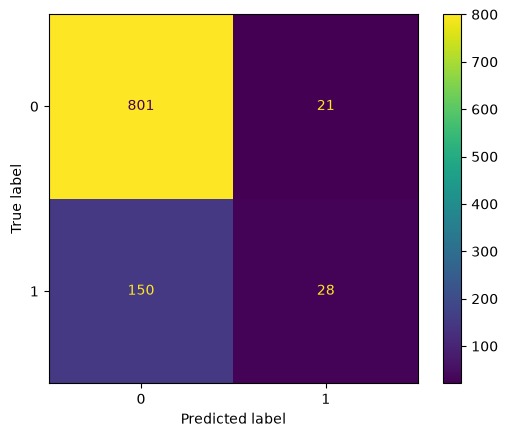

In [15]:
logistic_model = get_logisitic_regression()
y_val_pred = logistic_model.predict(x_val)
display_metric(y_val, y_val_pred)

### 2.2 Random Forest

In [16]:
def get_random_forest():
    first_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
    ])

    params_grid = {
        "classifier__n_estimators":[100, 200],
        "classifier__max_depth":[5,8,10,20]
    }

    gridSearch = GridSearchCV(estimator=first_pipeline, param_grid=params_grid, cv=5, scoring='average_precision')
    gridSearch.fit(x_train, y_train)

    return gridSearch

In [17]:
random_forest_model = get_random_forest()
rf_pred_y_val = random_forest_model.predict(x_val)
rf_pred_y_val_proba = random_forest_model.predict_proba(x_val)

f1_score: %56.29
recall_score: %74.1573
precision_score: %45.3608
--------------------------------------------------


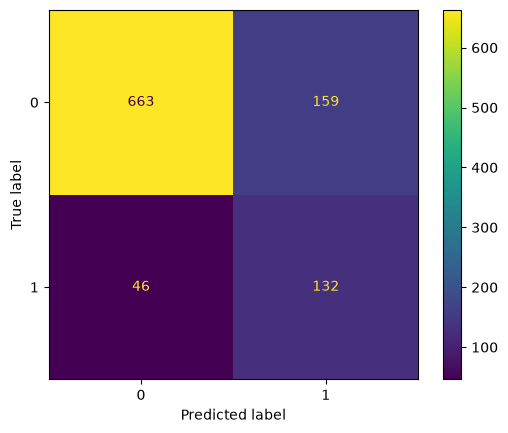

In [18]:
rf_pred_y_val_proba.shape

# for a in rf_pred_y_val_proba:
y_pred_custom = (rf_pred_y_val_proba[:, 1] >= 0.2127).astype(int)
display_metric(y_val, y_pred_custom)

### 2.3 SVM

In [19]:
def get_svm():
    first_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ('classifier', SVC(random_state=RANDOM_STATE, probability=True))
    ])

    params_grid = {
        "classifier__C":[0.01, 0.1, 1],
        # "classifier__penalty":["l1", "l2"],
        # "classifier__solver":["liblinear", "newton-cg", "sag"]
    }

    gridSearch = GridSearchCV(estimator=first_pipeline, param_grid=params_grid, cv=5, scoring="f1")
    gridSearch.fit(x_train, y_train)

    return gridSearch

In [20]:
svm_model = get_svm()

In [21]:
svm_pred_y_val = svm_model.predict(x_val)
svm_pred_y_val_proba = svm_model.predict_proba(x_val)

f1_score: %42.0635
recall_score: %29.7753
precision_score: %71.6216
--------------------------------------------------


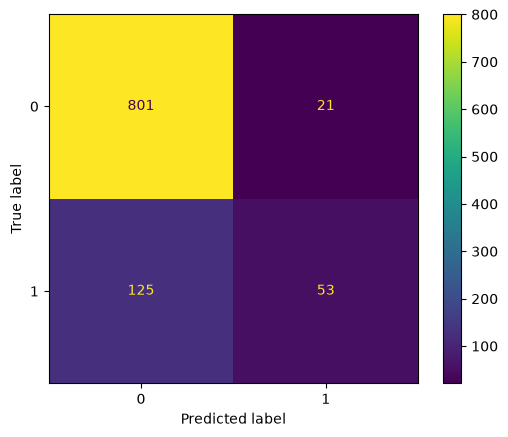

In [22]:
display_metric(y_val, svm_pred_y_val)

In [23]:
get_best_threshold(y_val, svm_pred_y_val_proba[:,1])

Optimal Threshold: 0.1908
At this threshold -> TPR (Recall): 0.6124, FPR: 0.1350


f1_score: %54.7739
recall_score: %61.236
precision_score: %49.5455
--------------------------------------------------
f1_score: %45.4545
recall_score: %33.7079
precision_score: %69.7674
--------------------------------------------------


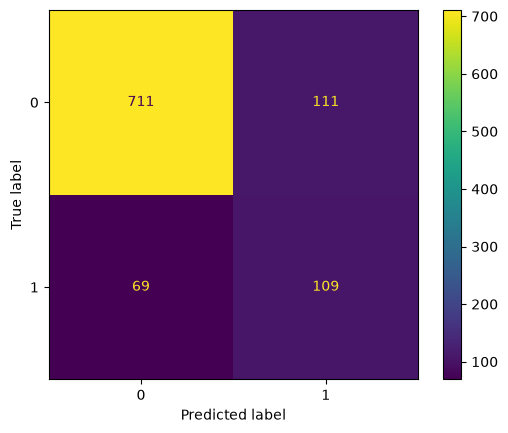

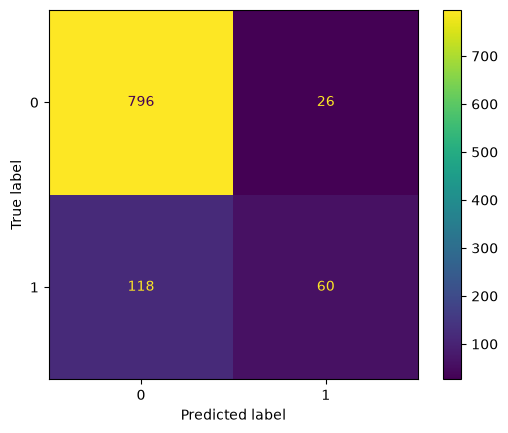

In [24]:
svm_pred_y_val

predictions = (svm_pred_y_val_proba[:,1] >= 0.1908).astype(int)
display_metric(y_val, predictions)

predictions = (svm_pred_y_val_proba[:,1] >= 0.5).astype(int)
display_metric(y_val, predictions)

# 2.4 Decision Tree

In [25]:
def get_tree():
    first_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

    params_grid = {
        # "classifier__C":[0.01, 0.1, 1],
        # "classifier__penalty":["l1", "l2"],
        # "classifier__solver":["liblinear", "newton-cg", "sag"]
    }

    gridSearch = GridSearchCV(estimator=first_pipeline, param_grid=params_grid, cv=5, scoring="f1")
    gridSearch.fit(x_train, y_train)

    return gridSearch

In [26]:
decision_tree = get_tree()

f1_score: %45.7584
recall_score: %50.0
precision_score: %42.1801
--------------------------------------------------


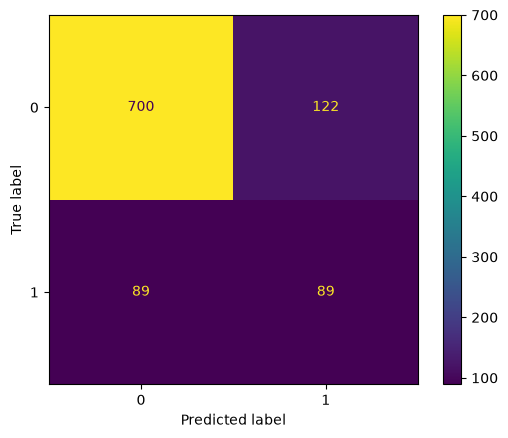

In [27]:
tree_pred_y_val = decision_tree.predict(x_val)
tree_pred_y_val_proba = decision_tree.predict_proba(x_val)
display_metric(y_val, tree_pred_y_val)

In [28]:
get_best_threshold(y_val, tree_pred_y_val_proba[:,1])

Optimal Threshold: 1.0000
At this threshold -> TPR (Recall): 0.5000, FPR: 0.1484


In [29]:
# display_metric(y_val, rf_pred_y_val)

In [30]:
# from sklearn.model_selection import TunedThresholdClassifierCV

# # Automatically tune the threshold to maximize F1-score during fitting
# tuned_model = TunedThresholdClassifierCV(
#     estimator=rf.best_estimator_,
#     scoring="f1",
#     cv=5
# )

# tuned_model.fit(x_train, y_train)

# # Calling predict() now uses the automatically tuned threshold instead of 0.5
# y_pred_tuned = tuned_model.predict(x_val)
# display_metric(y_pred_tuned, y_val)

In [31]:
rf_pred_y_val_proba.shape

(1000, 2)

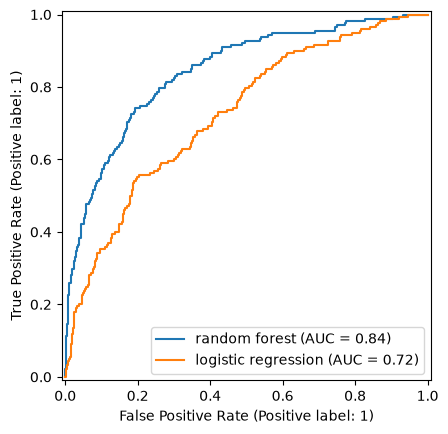

In [32]:


fig, ax = plt.subplots()

RocCurveDisplay.from_estimator(random_forest_model, x_val, y_val, ax=ax, name="random forest")
RocCurveDisplay.from_estimator(logistic_model, x_val, y_val, ax=ax, name="logistic regression")

plt.show()

# Evaluation

In [33]:
models = {
    "svm":svm_model,
    "logistic_model": logistic_model,
    "random_forest": random_forest_model,
    "decision_tree": decision_tree
}

svm
f1_score: %42.0635
recall_score: %29.7753
precision_score: %71.6216
--------------------------------------------------
svm_best_threshold
f1_score: %54.7739
recall_score: %61.236
precision_score: %49.5455
--------------------------------------------------
logistic_model
f1_score: %24.6696
recall_score: %15.7303
precision_score: %57.1429
--------------------------------------------------
logistic_model_best_threshold
f1_score: %44.6469
recall_score: %55.0562
precision_score: %37.5479
--------------------------------------------------
random_forest
f1_score: %45.2107
recall_score: %33.1461
precision_score: %71.0843
--------------------------------------------------
random_forest_best_threshold
f1_score: %56.29
recall_score: %74.1573
precision_score: %45.3608
--------------------------------------------------
decision_tree
f1_score: %45.7584
recall_score: %50.0
precision_score: %42.1801
--------------------------------------------------
decision_tree_best_threshold
f1_score: %45.7584


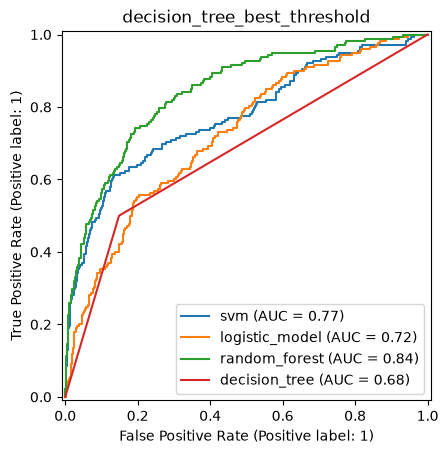

In [64]:
fig, ax = plt.subplots()

data = {
    "Model":[],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

def append_to_data(name, f1, recall, precision):
    data['Model'].append(name)
    data['F1-Score'].append(f1*100)
    data['Recall'].append(recall*100)
    data['Precision'].append(precision*100)


for name, model in models.items():
    y_pred = model.predict(x_val)
    y_pred_probs = model.predict_proba(x_val)[:,1]

    print(name)
    f1, recall, precision = display_metric(y_val, y_pred, name, ConfusionMatrix=False)
    append_to_data(name, f1, recall, precision)

    name2 = name + "_best_threshold"
    print(name2)
    best_threshold = get_best_threshold(y_val, y_pred_probs, printing=False)
    y_pred_2 = (y_pred_probs >= best_threshold).astype(int)
    f1, recall, precision = display_metric(y_val, y_pred_2, name2, ConfusionMatrix=False)
    append_to_data(name2, f1, recall, precision)

    RocCurveDisplay.from_estimator(model, x_val, y_val, ax=ax, name=name)


plt.show()

    

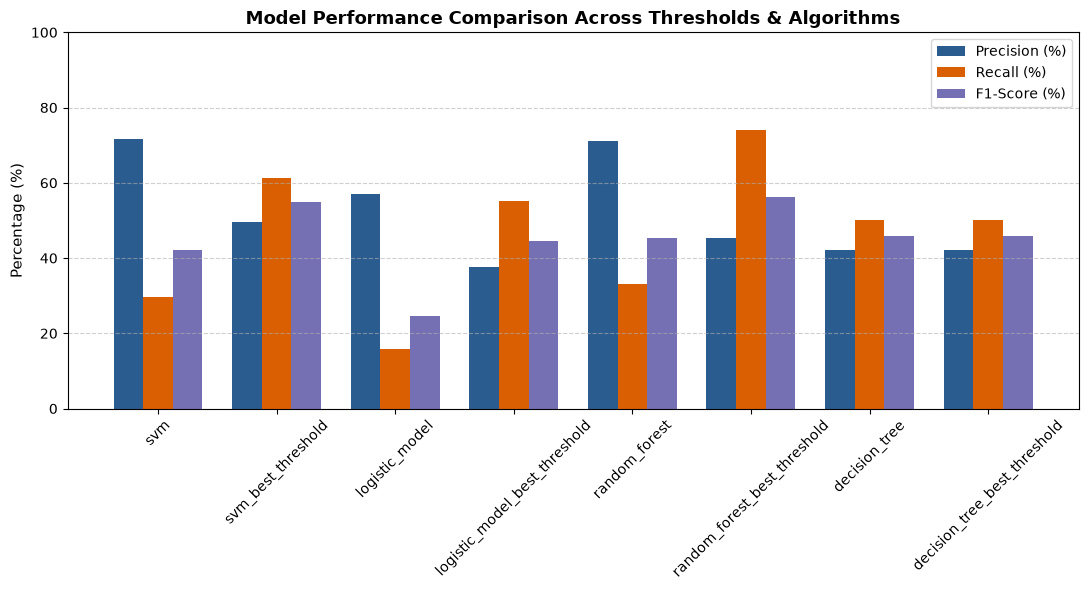

In [67]:

df = pd.DataFrame(data)


x = np.arange(len(df["Model"]))
width = 0.25

# Create plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    x - width,
    df["Precision"],
    width,
    label="Precision (%)",
    color="#2b5c8f",
)
ax.bar(x, df["Recall"], width, label="Recall (%)", color="#d95f02")
ax.bar(
    x + width,
    df["F1-Score"],
    width,
    label="F1-Score (%)",
    color="#7570b3",
)

# Styling
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_title(
    "Model Performance Comparison Across Thresholds & Algorithms",
    fontsize=13,
    fontweight="bold",
)
plt.xticks(rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(df["Model"], fontsize=10)
ax.set_ylim(0, 100)
ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()